<a href="https://colab.research.google.com/github/tomasbelak24/deeplearning-vision/blob/main/hw1/optimizers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Optimization (4pt)

Test training with Adam, SGD or RMSProp optimizers. Run at least 4 different configurations (different steps, different alpha, beta, etc). For this task, it is advisable to use the graphs in the pdf.

Choose one method and additionally test three other minibatch sizes for it.

In [ ]:
!mkdir -p baseline
# I might make the repo private in the future so the files from /baseline directory from the zip file might have to be used
!wget -O baseline/baseline_model.pth https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/models/baseline_model.pth
!wget -O baseline/baseline_results.json https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/results/baseline_results.json


--2025-11-09 21:08:00--  https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/models/baseline_model.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 381333 (372K) [application/octet-stream]
Saving to: ‘baseline/baseline_model.pth’

baseline/baseline_m 100%[===================>] 372.40K  --.-KB/s    in 0.006s  

2025-11-09 21:08:00 (63.9 MB/s) - ‘baseline/baseline_model.pth’ saved [381333/381333]

--2025-11-09 21:08:01--  https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/results/baseline_results.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443.

In [ ]:
import json

with open('baseline/baseline_results.json', 'r') as f:
    baseline_results = json.load(f)

baseline_train_losses = baseline_results['train_losses']
baseline_val_losses = baseline_results['val_losses']
baseline_val_accs = baseline_results['val_accuracies']

print("Baseline results loaded successfully.")

Baseline results loaded successfully.


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

import numpy as np
from matplotlib import pyplot as plt

100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


torch.Size([1, 3, 32, 32])


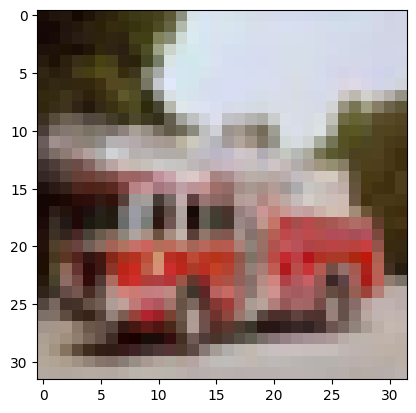

tensor([9])
truck
torch.Size([1, 3, 32, 32])


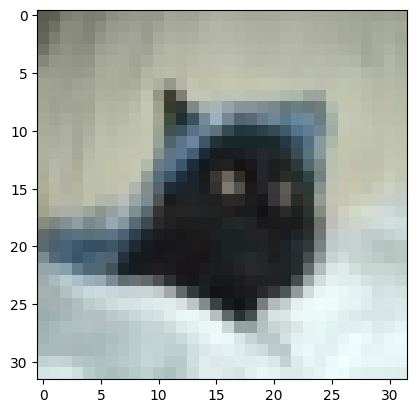

tensor([3])
cat
torch.Size([1, 3, 32, 32])


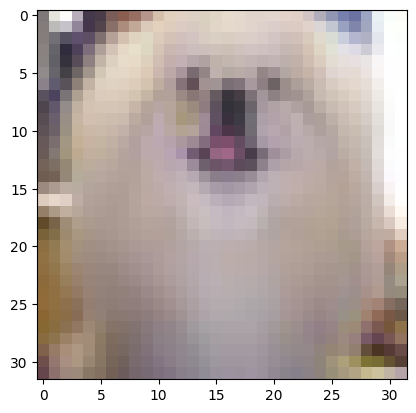

tensor([5])
dog
torch.Size([1, 3, 32, 32])


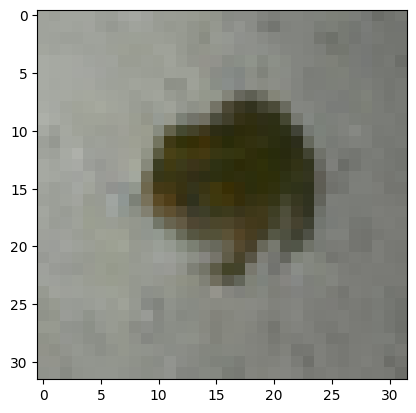

tensor([6])
frog
torch.Size([1, 3, 32, 32])


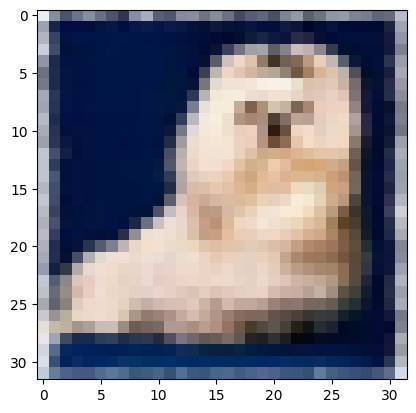

tensor([5])
dog
torch.Size([1, 3, 32, 32])


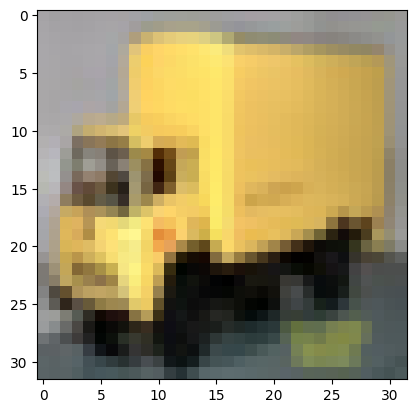

tensor([9])
truck
torch.Size([1, 3, 32, 32])


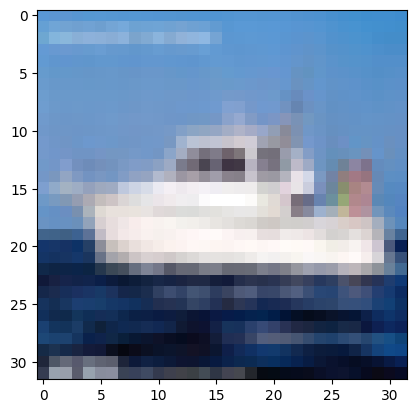

tensor([8])
ship
torch.Size([1, 3, 32, 32])


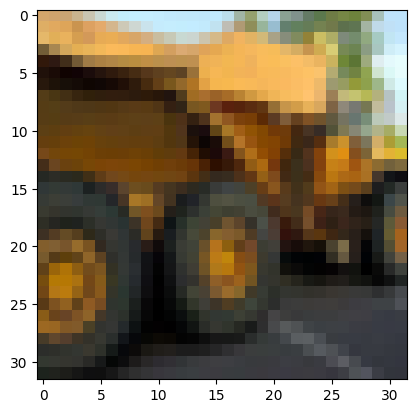

tensor([9])
truck
torch.Size([1, 3, 32, 32])


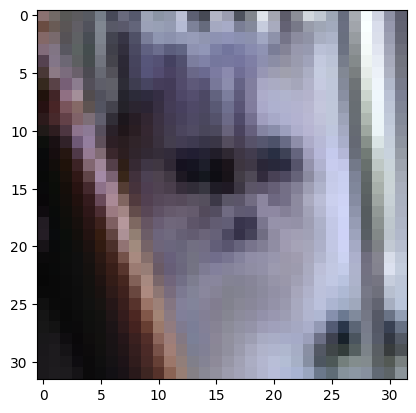

tensor([3])
cat
torch.Size([1, 3, 32, 32])


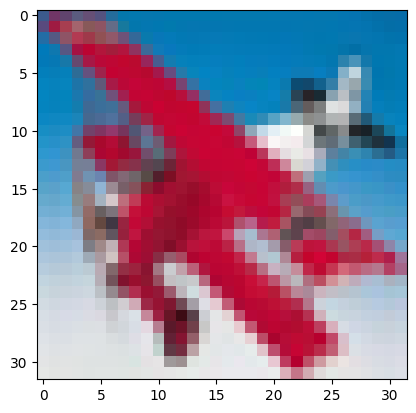

tensor([0])
plane
torch.Size([1, 3, 32, 32])


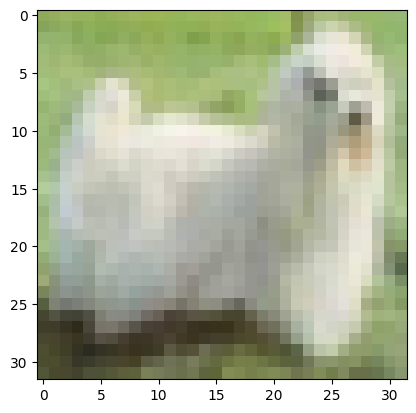

tensor([5])
dog


In [ ]:
# @title Loading CIFAR10 dataset

#reused code from the 5th lab

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

transform = transforms.ToTensor()

dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# for reproducibility
trainset, valset = torch.utils.data.random_split(dataset, [45000, 5000], generator=torch.Generator().manual_seed(42))

previewloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=True)

for i, sample in enumerate(previewloader):
  if i > 10:
    break
  x, y = sample
  print(x.shape)
  img = np.moveaxis(x.numpy()[0], 0, -1)
  plt.imshow(img)
  plt.show()
  print(y)
  print(classes[y.item()])

### Model architecture

In [ ]:
from torch.nn import ReLU, Softmax, Sequential, Linear, Conv2d, MaxPool2d, Flatten, AdaptiveAvgPool2d

def build_model_task3(num_classes=10):
  model = Sequential(
        Conv2d(3, 32, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),
        Conv2d(32, 64, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),
        Conv2d(64, 128, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),

        AdaptiveAvgPool2d(1),
        Flatten(),
        Linear(128, num_classes)
    )

  model_inference = Sequential(model, Softmax(dim=1))
  return model, model_inference

model, model_inference = build_model_task3()

out = model_inference(torch.from_numpy(np.zeros([1, 3, 32, 32], dtype=np.float32)))
print(out.size())
print(out)
print(classes[out.argmax().item()])

torch.Size([1, 10])
tensor([[0.1056, 0.1013, 0.0935, 0.0969, 0.1053, 0.0982, 0.0967, 0.0985, 0.1048,
         0.0993]], grad_fn=<SoftmaxBackward0>)
plane


In [ ]:
def one_epoch(model, loss, optimizer, dataloader_train, dataloader_val, verbose=True):
  train_losses = []
  val_losses = []

  model.train()
  for i, batch in enumerate(dataloader_train):
    x, y = batch[0].to(device), batch[1].to(device)
    optimizer.zero_grad()

    out = model(x)
    loss = ce_loss(out, y)
    loss.backward()
    train_losses.append(loss.item())
    optimizer.step()
    if i % 100 == 0 and verbose:
      print("Training loss at step {}: {}".format(i, loss.item()))

  model.eval()
  with torch.no_grad():
    correct = 0
    total = 0
    for i, batch in enumerate(dataloader_val):
      x, y = batch[0].to(device), batch[1].to(device)

      out = model(x)
      loss = ce_loss(out, y)
      acc = torch.sum(torch.argmax(out, dim=-1) == y)
      correct += acc.item()
      total += len(batch[1])
      val_losses.append(loss.item())

  val_acc = correct / total

  return np.mean(train_losses), np.mean(val_losses), val_acc

### Experiments with different optimizers

Using device:  cuda:0
Trying optimizer: adam_lr0.01_beta0.85
[{'lr': 0.01, 'betas': (0.85, 0.99), 'eps': 1e-08, 'weight_decay': 0, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': False, 'params': [0, 1, 2, 3, 4, 5, 6, 7]}]
Val loss at epoch 0: 1.756165454342107
Val acc at epoch 0: 0.3482
Val loss at epoch 1: 1.6428331827661793
Val acc at epoch 1: 0.3876
Val loss at epoch 2: 1.5494849309799776
Val acc at epoch 2: 0.4252
Val loss at epoch 3: 1.505235528490346
Val acc at epoch 3: 0.4468
Val loss at epoch 4: 1.5506535927960827
Val acc at epoch 4: 0.4474
Val loss at epoch 5: 1.4194518635227422
Val acc at epoch 5: 0.4896
Val loss at epoch 6: 1.4813268617459923
Val acc at epoch 6: 0.4704
Val loss at epoch 7: 1.365791353070812
Val acc at epoch 7: 0.5136
Val loss at epoch 8: 1.359871381786978
Val acc at epoch 8: 0.5046
Val loss at epoch 9: 1.3850486741703787
Val acc at epoch 9: 0.4968
Val loss at epoch 

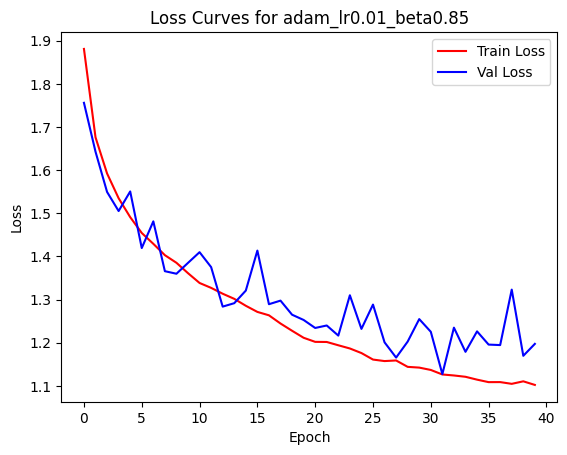

Trying optimizer: adam_lr0.0001
[{'lr': 0.0001, 'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': False, 'params': [0, 1, 2, 3, 4, 5, 6, 7]}]
Val loss at epoch 0: 1.916678149988697
Val acc at epoch 0: 0.3146
Val loss at epoch 1: 1.7666452439727298
Val acc at epoch 1: 0.351
Val loss at epoch 2: 1.6836981735411722
Val acc at epoch 2: 0.3794
Val loss at epoch 3: 1.6449213529088695
Val acc at epoch 3: 0.3988
Val loss at epoch 4: 1.6053654099725614
Val acc at epoch 4: 0.4186
Val loss at epoch 5: 1.5823219186940771
Val acc at epoch 5: 0.4344
Val loss at epoch 6: 1.5696053117703481
Val acc at epoch 6: 0.4396
Val loss at epoch 7: 1.5313867398887684
Val acc at epoch 7: 0.4542
Val loss at epoch 8: 1.5258767483340707
Val acc at epoch 8: 0.453
Val loss at epoch 9: 1.5073312991743635
Val acc at epoch 9: 0.4698
Val loss at epoch 10: 1.4894370144339883
Val

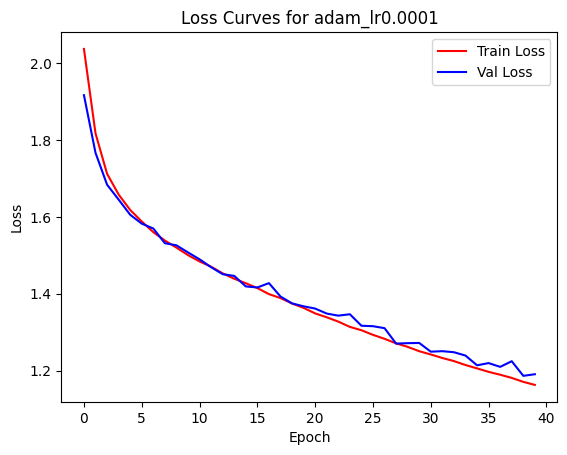

Trying optimizer: SGD_lr0.01
[{'lr': 0.01, 'momentum': 0.9, 'dampening': 0, 'weight_decay': 0, 'nesterov': False, 'maximize': False, 'foreach': None, 'differentiable': False, 'fused': None, 'params': [0, 1, 2, 3, 4, 5, 6, 7]}]
Val loss at epoch 0: 1.7378868601124757
Val acc at epoch 0: 0.3684
Val loss at epoch 1: 1.4978144320712727
Val acc at epoch 1: 0.4614
Val loss at epoch 2: 1.2584893737628962
Val acc at epoch 2: 0.5466
Val loss at epoch 3: 1.2253582466180157
Val acc at epoch 3: 0.5568
Val loss at epoch 4: 1.1232091298528537
Val acc at epoch 4: 0.5958
Val loss at epoch 5: 1.0238568482884935
Val acc at epoch 5: 0.64
Val loss at epoch 6: 1.000881759224424
Val acc at epoch 6: 0.651
Val loss at epoch 7: 0.948669693652232
Val acc at epoch 7: 0.6682
Val loss at epoch 8: 0.9206051289275953
Val acc at epoch 8: 0.6796
Val loss at epoch 9: 0.8807491922074822
Val acc at epoch 9: 0.6942
Val loss at epoch 10: 0.8586299903453536
Val acc at epoch 10: 0.7048
Val loss at epoch 11: 0.812245090296314

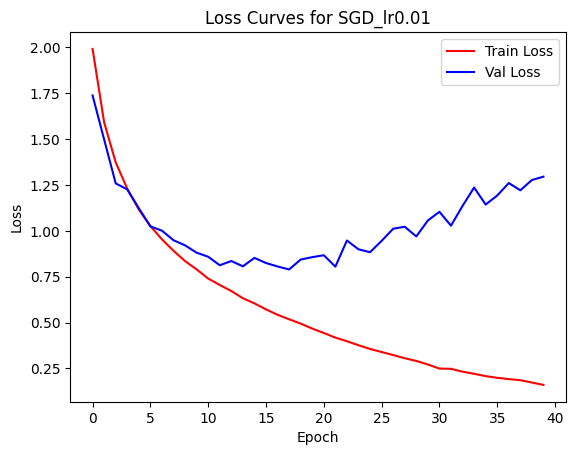

Trying optimizer: SGD_lr0.1
[{'lr': 0.1, 'momentum': 0.9, 'dampening': 0, 'weight_decay': 0, 'nesterov': False, 'maximize': False, 'foreach': None, 'differentiable': False, 'fused': None, 'params': [0, 1, 2, 3, 4, 5, 6, 7]}]
Val loss at epoch 0: 1.7541442950060413
Val acc at epoch 0: 0.3566
Val loss at epoch 1: 1.5487769667510014
Val acc at epoch 1: 0.4302
Val loss at epoch 2: 1.5153323601765238
Val acc at epoch 2: 0.441
Val loss at epoch 3: 1.505346722663588
Val acc at epoch 3: 0.4592
Val loss at epoch 4: 1.3494303230267422
Val acc at epoch 4: 0.5208
Val loss at epoch 5: 1.3081276101671206
Val acc at epoch 5: 0.5354
Val loss at epoch 6: 1.2180810973143121
Val acc at epoch 6: 0.5684
Val loss at epoch 7: 1.197217459511605
Val acc at epoch 7: 0.5776
Val loss at epoch 8: 1.178674449966212
Val acc at epoch 8: 0.5808
Val loss at epoch 9: 1.1701700284982184
Val acc at epoch 9: 0.5972
Val loss at epoch 10: 1.4209820142217502
Val acc at epoch 10: 0.519
Val loss at epoch 11: 1.2254641021892523


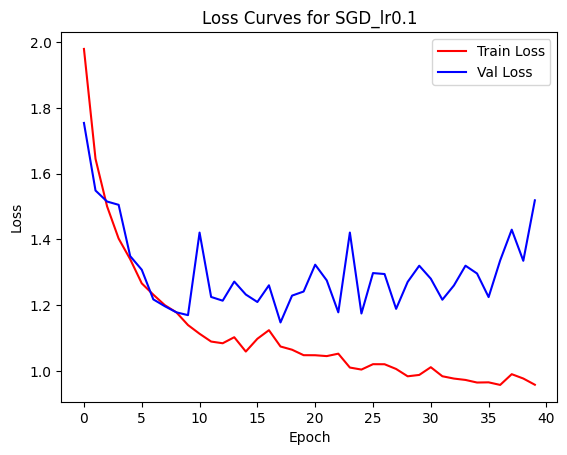

Trying optimizer: RMSprop
[{'lr': 0.01, 'momentum': 0, 'alpha': 0.99, 'eps': 1e-08, 'centered': False, 'weight_decay': 0, 'capturable': False, 'foreach': None, 'maximize': False, 'differentiable': False, 'params': [0, 1, 2, 3, 4, 5, 6, 7]}]
Val loss at epoch 0: 1.8482030166941843
Val acc at epoch 0: 0.3336
Val loss at epoch 1: 1.569745982528492
Val acc at epoch 1: 0.4296
Val loss at epoch 2: 1.5678593877014841
Val acc at epoch 2: 0.4548
Val loss at epoch 3: 1.4290505260418935
Val acc at epoch 3: 0.4834
Val loss at epoch 4: 1.7150271090732259
Val acc at epoch 4: 0.4436
Val loss at epoch 5: 1.226112865718307
Val acc at epoch 5: 0.5576
Val loss at epoch 6: 1.5178463948760064
Val acc at epoch 6: 0.4756
Val loss at epoch 7: 1.246005587137429
Val acc at epoch 7: 0.5618
Val loss at epoch 8: 1.2043807628048453
Val acc at epoch 8: 0.5842
Val loss at epoch 9: 1.3163883913854124
Val acc at epoch 9: 0.5404
Val loss at epoch 10: 2.6138324130112958
Val acc at epoch 10: 0.2426
Val loss at epoch 11: 1

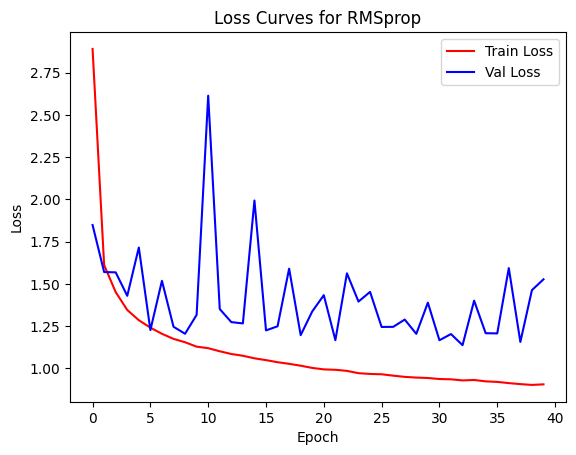

In [ ]:
from torch.optim import Adam, SGD, RMSprop

configs = [ {'name': 'adam_lr0.01_beta0.85','optimizer': lambda: Adam(model.parameters(), lr=0.01, betas=(0.85, 0.99))},
            {'name': 'adam_lr0.0001','optimizer': lambda: Adam(model.parameters(), lr=0.0001)},
            {'name': 'SGD_lr0.01', 'optimizer': lambda: SGD(model.parameters(), lr=0.01, momentum=0.9)},
            {'name': 'SGD_lr0.1', 'optimizer': lambda: SGD(model.parameters(), lr=0.1, momentum=0.9)},
            {'name': 'RMSprop', 'optimizer': lambda: RMSprop(model.parameters())}
          ]

### TODO: dokoncit config setup

losses = {config['name']: ([], []) for config in configs}
accuracies = {config['name']: [] for config in configs}

batch_size = 32

dataloader_train = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
dataloader_val = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

ce_loss = torch.nn.CrossEntropyLoss().to(device)

for config in configs:
    print(f"Trying optimizer: {config['name']}")

    model, model_inference = build_model_task3()
    model.to(device)
    model_inference.to(device)

    optimizer = config['optimizer']()
    print(optimizer.state_dict()['param_groups'])

    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accs = []

    for e in range(40):
        train_loss, val_loss, val_acc = one_epoch(model, ce_loss, optimizer, dataloader_train, dataloader_val, False)

        print(f"Val loss at epoch {e}: {val_loss}")
        print(f"Val acc at epoch {e}: {val_acc}")

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_val_accs.append(val_acc)

    losses[config['name']][0].append(epoch_train_losses)
    losses[config['name']][1].append(epoch_val_losses)
    accuracies[config['name']].append(epoch_val_accs)

    plt.plot(epoch_train_losses, c='r', label='Train Loss')
    plt.plot(epoch_val_losses, c='b', label='Val Loss')
    plt.title(f"Loss Curves for {config['name']}")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [ ]:
import json

results_to_dump = {
    'losses': losses,
    'accuracies': accuracies
}

output_filename = 'optimizers_results.json'

with open(output_filename, 'w') as f:
    json.dump(results_to_dump, f)

print(f"Results dumped to {output_filename}")

Results dumped to optimizers_results.json


### Comaprison to baseline

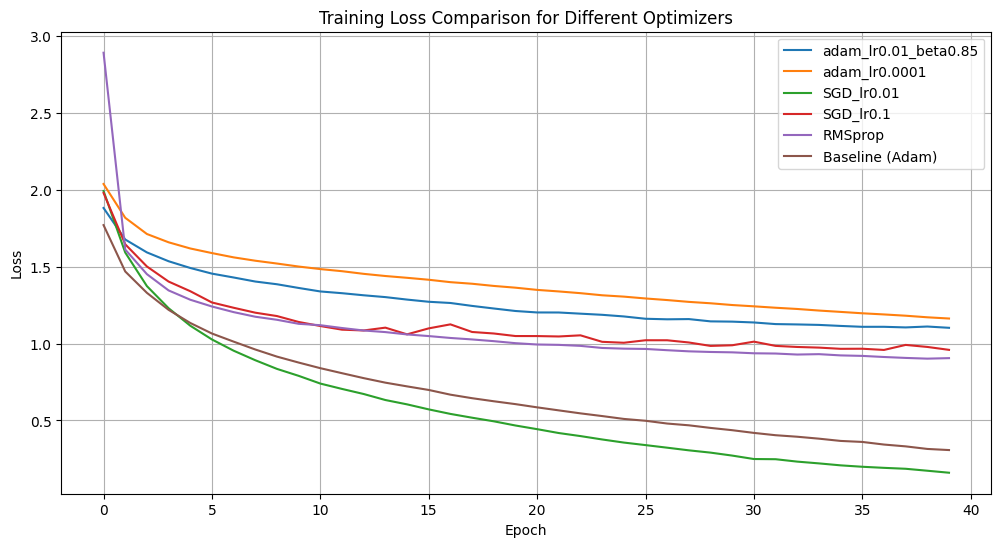

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][0][0], label=optimizer_name['name'])

plt.plot(baseline_train_losses, label='Baseline (Adam)')

plt.title('Training Loss Comparison for Different Optimizers')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

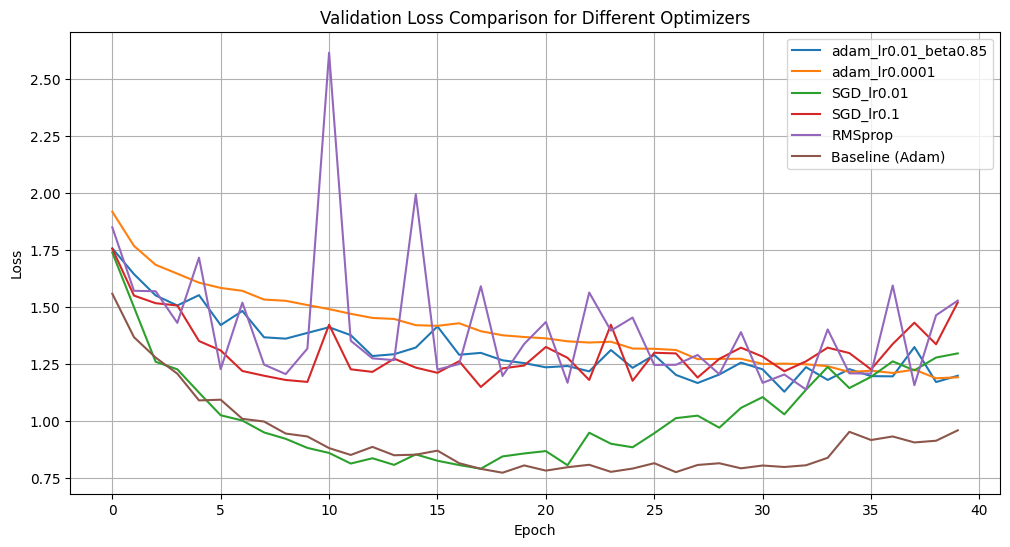

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][1][0], label=optimizer_name['name'])

plt.plot(baseline_val_losses, label='Baseline (Adam)')

plt.title('Validation Loss Comparison for Different Optimizers')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

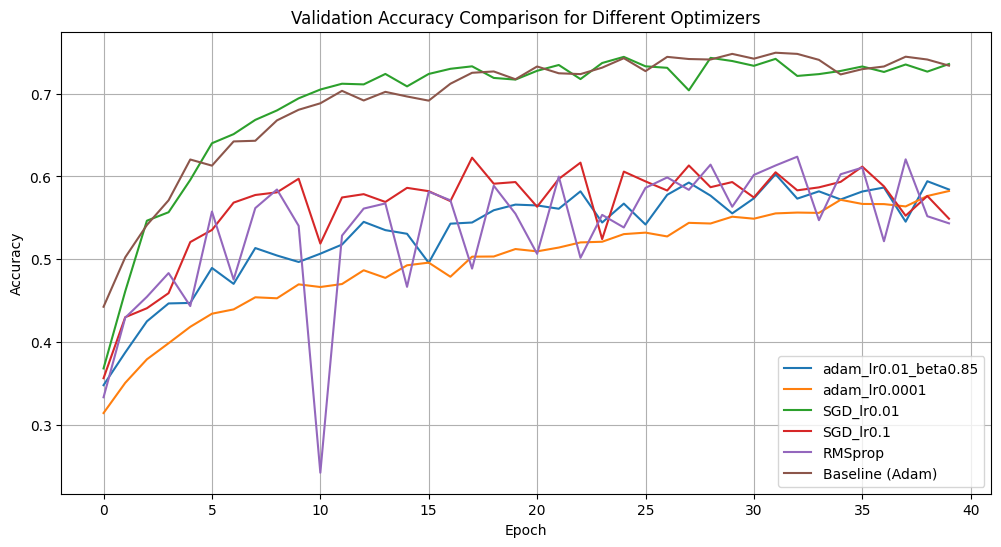

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(accuracies[optimizer_name['name']][0], label=optimizer_name['name'])

plt.plot(baseline_val_accs, label='Baseline (Adam)')

plt.title('Validation Accuracy Comparison for Different Optimizers')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

summary_data = {}

summary_data['Baseline (Adam)'] = {
    'Final Train Loss': baseline_train_losses[-1],
    'Final Val Loss': baseline_val_losses[-1],
    'Final Val Accuracy': baseline_val_accs[-1]
}

for config in configs:
    summary_data[config['name']] = {
        'Final Train Loss': losses[config['name']][0][0][-1],
        'Final Val Loss': losses[config['name']][1][0][-1],
        'Final Val Accuracy': accuracies[config['name']][0][-1]
    }

summary_df = pd.DataFrame.from_dict(summary_data, orient='index')
display(summary_df)

,Final Train Loss,Final Val Loss,Final Val Accuracy
Baseline (Adam),0.712818,0.845021,0.7098
adam_lr0.01_beta0.85,1.045242,1.266049,0.5756
adam_lr0.0001,1.410405,1.418583,0.4910
SGD_lr0.01,0.601520,0.792280,0.7262
SGD_lr0.1,2.310532,2.309857,0.0942
RMSprop,1.053760,1.602071,0.5168


### Batch size experiments

Using device:  cuda:0
Trying batch size: batch_size_64
Val loss at epoch 0: 1.624217092236386
Val acc at epoch 0: 0.4118
Val loss at epoch 1: 1.4928661071801488
Val acc at epoch 1: 0.4654
Val loss at epoch 2: 1.398254091226602
Val acc at epoch 2: 0.504
Val loss at epoch 3: 1.323878890351404
Val acc at epoch 3: 0.5402
Val loss at epoch 4: 1.2805014335656468
Val acc at epoch 4: 0.5376
Val loss at epoch 5: 1.2107778847972048
Val acc at epoch 5: 0.575
Val loss at epoch 6: 1.1557520461987845
Val acc at epoch 6: 0.5942
Val loss at epoch 7: 1.1303710914865326
Val acc at epoch 7: 0.6066
Val loss at epoch 8: 1.0930141482172133
Val acc at epoch 8: 0.6162
Val loss at epoch 9: 1.072401090513302
Val acc at epoch 9: 0.625
Val loss at epoch 10: 1.0110226756409755
Val acc at epoch 10: 0.642
Val loss at epoch 11: 0.9748363057269326
Val acc at epoch 11: 0.653
Val loss at epoch 12: 0.9857549810711341
Val acc at epoch 12: 0.6542
Val loss at epoch 13: 0.950252466563937
Val acc at epoch 13: 0.6628
Val loss 

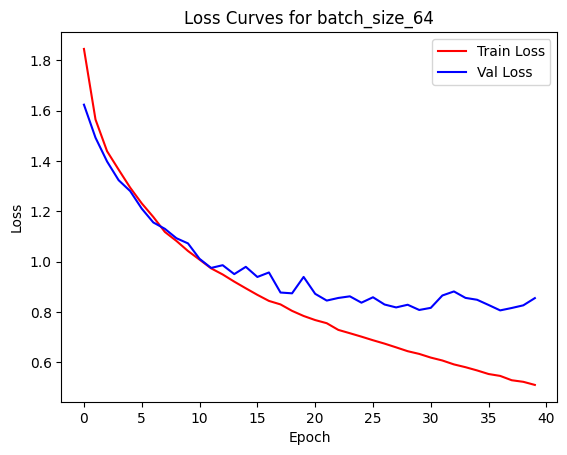

Trying batch size: batch_size_128
Val loss at epoch 0: 1.70650295317173
Val acc at epoch 0: 0.3902
Val loss at epoch 1: 1.5879772692918777
Val acc at epoch 1: 0.4284
Val loss at epoch 2: 1.5183669537305833
Val acc at epoch 2: 0.4646
Val loss at epoch 3: 1.4297980576753617
Val acc at epoch 3: 0.4872
Val loss at epoch 4: 1.3829872727394104
Val acc at epoch 4: 0.4938
Val loss at epoch 5: 1.3169339835643767
Val acc at epoch 5: 0.5286
Val loss at epoch 6: 1.2636222004890443
Val acc at epoch 6: 0.5492
Val loss at epoch 7: 1.3383882701396943
Val acc at epoch 7: 0.5322
Val loss at epoch 8: 1.2003464192152022
Val acc at epoch 8: 0.576
Val loss at epoch 9: 1.1585443034768104
Val acc at epoch 9: 0.5956
Val loss at epoch 10: 1.118039059638977
Val acc at epoch 10: 0.6096
Val loss at epoch 11: 1.113752080500126
Val acc at epoch 11: 0.6058
Val loss at epoch 12: 1.0954346477985382
Val acc at epoch 12: 0.6182
Val loss at epoch 13: 1.0742478981614112
Val acc at epoch 13: 0.6224
Val loss at epoch 14: 1.0

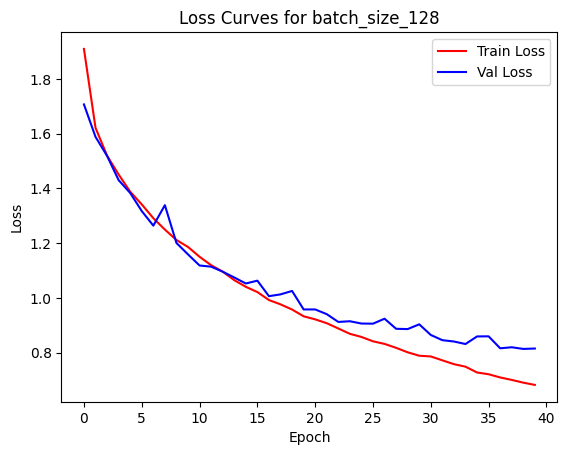

Trying batch size: batch_size_16
Val loss at epoch 0: 1.44254036795217
Val acc at epoch 0: 0.4736
Val loss at epoch 1: 1.2237364847820027
Val acc at epoch 1: 0.5602
Val loss at epoch 2: 1.1122173844054104
Val acc at epoch 2: 0.6132
Val loss at epoch 3: 1.0362022696211697
Val acc at epoch 3: 0.6336
Val loss at epoch 4: 0.9568569105082807
Val acc at epoch 4: 0.6628
Val loss at epoch 5: 0.9171172543265187
Val acc at epoch 5: 0.6808
Val loss at epoch 6: 0.9340099034408411
Val acc at epoch 6: 0.6688
Val loss at epoch 7: 0.8885967502007469
Val acc at epoch 7: 0.69
Val loss at epoch 8: 0.8340519280098497
Val acc at epoch 8: 0.7088
Val loss at epoch 9: 0.8795755383210441
Val acc at epoch 9: 0.6896
Val loss at epoch 10: 0.7962508756227006
Val acc at epoch 10: 0.7196
Val loss at epoch 11: 0.8122855105910438
Val acc at epoch 11: 0.716
Val loss at epoch 12: 0.8185530530092434
Val acc at epoch 12: 0.721
Val loss at epoch 13: 0.7853325911985037
Val acc at epoch 13: 0.732
Val loss at epoch 14: 0.8230

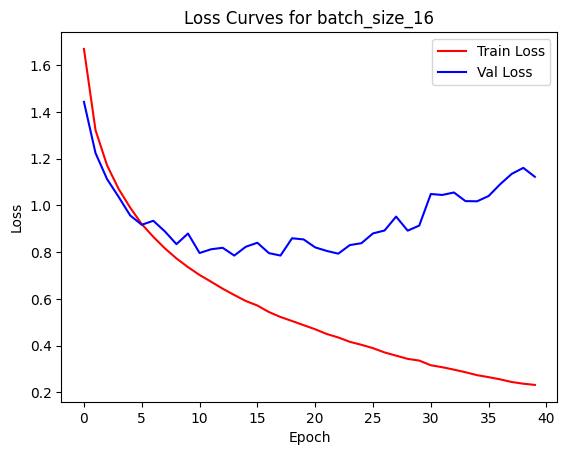

In [ ]:
from torch.optim import Adam

configs = [ {'name': 'batch_size_64','size': 64},
            {'name': 'batch_size_128','size': 128},
            {'name': 'batch_size_16', 'size': 16}
          ]


losses = {config['name']: ([], []) for config in configs}
accuracies = {config['name']: [] for config in configs}

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

ce_loss = torch.nn.CrossEntropyLoss().to(device)

for config in configs:
    print(f"Trying batch size: {config['name']}")

    model, model_inference = build_model_task3()
    model.to(device)
    model_inference.to(device)
    optimizer = Adam(model.parameters())


    batch_size = config['size']
    dataloader_train = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
    dataloader_val = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False)

    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accs = []

    for e in range(40):
        train_loss, val_loss, val_acc = one_epoch(model, ce_loss, optimizer, dataloader_train, dataloader_val, False)

        print(f"Val loss at epoch {e}: {val_loss}")
        print(f"Val acc at epoch {e}: {val_acc}")

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_val_accs.append(val_acc)

    losses[config['name']][0].append(epoch_train_losses)
    losses[config['name']][1].append(epoch_val_losses)
    accuracies[config['name']].append(epoch_val_accs)

    plt.plot(epoch_train_losses, c='r', label='Train Loss')
    plt.plot(epoch_val_losses, c='b', label='Val Loss')
    plt.title(f"Loss Curves for {config['name']}")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [ ]:
import json

results_to_dump = {
    'losses': losses,
    'accuracies': accuracies
}

output_filename = 'optimizers_batchsize_results.json'

with open(output_filename, 'w') as f:
    json.dump(results_to_dump, f)

print(f"Results dumped to {output_filename}")

Results dumped to optimizers_batchsize_results.json


### Comparison to baseline

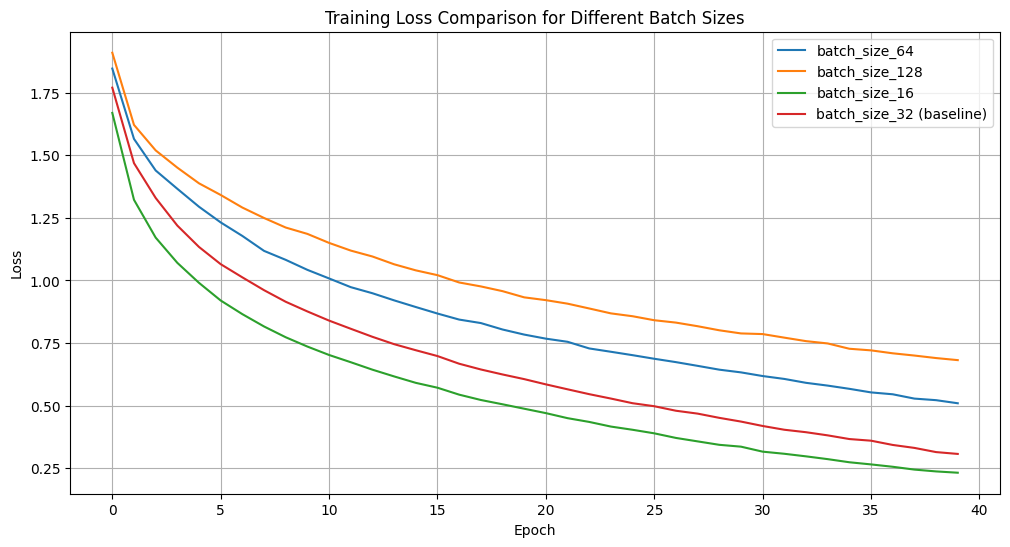

In [ ]:
plt.figure(figsize=(12, 6))
for config in configs:
    plt.plot(losses[config['name']][0][0], label=config['name'])

plt.plot(baseline_train_losses, label='batch_size_32 (baseline)')

plt.title('Training Loss Comparison for Different Batch Sizes')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

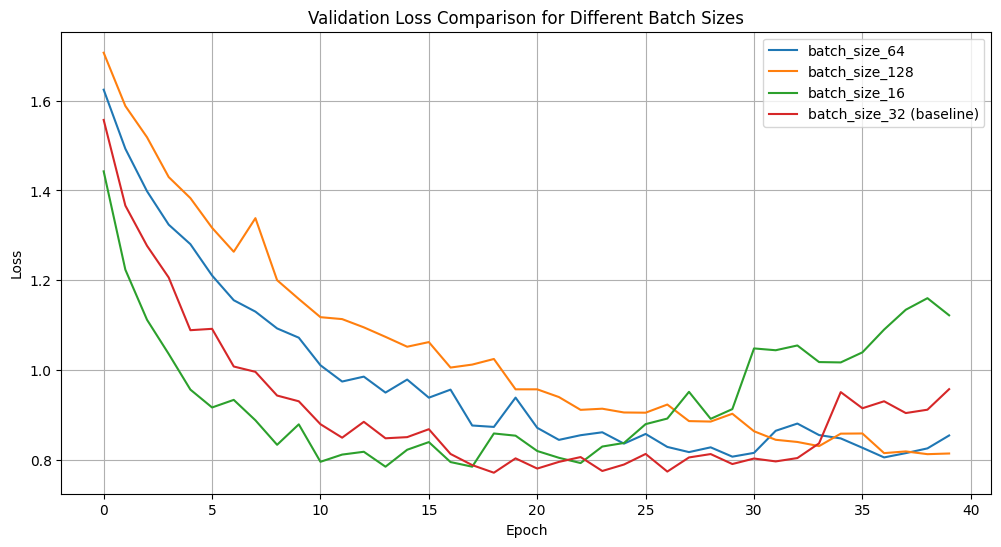

In [ ]:
plt.figure(figsize=(12, 6))
for config in configs:
    plt.plot(losses[config['name']][1][0], label=config['name'])

plt.plot(baseline_val_losses, label='batch_size_32 (baseline)')

plt.title('Validation Loss Comparison for Different Batch Sizes')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

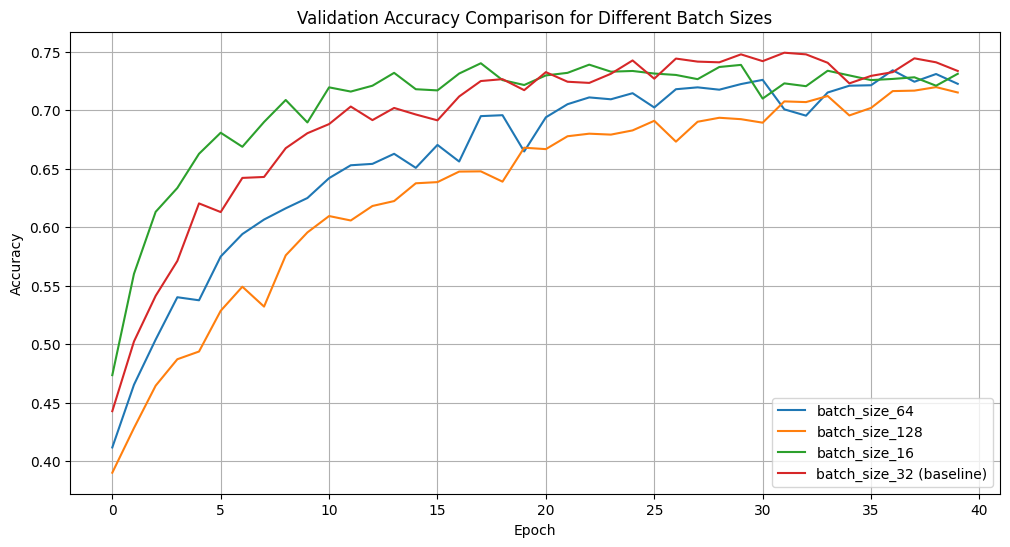

In [ ]:
plt.figure(figsize=(12, 6))
for config in configs:
    plt.plot(accuracies[config['name']][0], label=config['name'])

plt.plot(baseline_val_accs, label='batch_size_32 (baseline)')

plt.title('Validation Accuracy Comparison for Different Batch Sizes')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

summary_data = {}

summary_data['batch_size_32 (baseline)'] = {
    'Final Train Loss': baseline_train_losses[-1],
    'Final Val Loss': baseline_val_losses[-1],
    'Final Val Accuracy': baseline_val_accs[-1]
}

for config in configs:
    summary_data[config['name']] = {
        'Final Train Loss': losses[config['name']][0][0][-1],
        'Final Val Loss': losses[config['name']][1][0][-1],
        'Final Val Accuracy': accuracies[config['name']][0][-1]
    }

summary_df = pd.DataFrame.from_dict(summary_data, orient='index')
display(summary_df)

,Final Train Loss,Final Val Loss,Final Val Accuracy
batch_size_32 (baseline),0.307193,0.957867,0.7336
batch_size_64,0.509492,0.854813,0.7226
batch_size_128,0.681731,0.814711,0.7152
batch_size_16,0.232143,1.122198,0.7312
